In [2]:
!pip install -q kaggle

In [3]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hizkiagirsang","key":"b5e1445da0fd884f79f1c9decbda900d"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!kaggle datasets list -s "Netflix Movies and TV Shows Dataset"

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shivamb/netflix-shows                                           Netflix Movies and TV Shows                            1400865  2021-09-27 04:44:36.770000         749081       9851                1  
rahulvyasm/netflix-movies-and-tv-shows                          Netflix Movies and TV Shows                            1412315  2024-04-10 09:48:38.770000          42597        669                1  
thedevastator/the-ultimate-netflix-tv-shows-and-movies-dataset  Netflix TV Shows and Movies (2022 Updated)             1901586  2022-11-27 20:41:41.830000          12901        118                1  


In [7]:
!kaggle datasets download -d shivamb/netflix-shows

Dataset URL: https://www.kaggle.com/datasets/shivamb/netflix-shows
License(s): CC0-1.0
100% 1.34M/1.34M [00:00<00:00, 75.3MB/s]



In [8]:
!unzip netflix-shows.zip

Archive:  netflix-shows.zip
  inflating: netflix_titles.csv      


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('netflix_titles.csv')
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [17]:
# Cek informasi data
print(df.info())

# Cek data kosong
print(df.isnull().sum())

# Hapus data kosong pada kolom penting
df = df.dropna(subset=['director', 'country', 'date_added'])

# Bersihkan spasi di kolom date_added
df['date_added'] = df['date_added'].str.strip()

# Ubah ke datetime (aman dari error)
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Optional: hapus yang gagal convert
df = df.dropna(subset=['date_added'])

# Lihat hasil setelah cleaning
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 5751 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5751 non-null   object
 1   type          5751 non-null   object
 2   title         5751 non-null   object
 3   director      5751 non-null   object
 4   cast          5336 non-null   object
 5   country       5751 non-null   object
 6   date_added    5751 non-null   object
 7   release_year  5751 non-null   int64 
 8   rating        5750 non-null   object
 9   duration      5748 non-null   object
 10  listed_in     5751 non-null   object
 11  description   5751 non-null   object
dtypes: int64(1), object(11)
memory usage: 584.1+ KB
None
show_id           0
type              0
title             0
director          0
cast            415
country           0
date_added        0
release_year      0
rating            1
duration          3
listed_in         0
description       0
dtype: int64

In [26]:
print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description',
       'Month'],
      dtype='object')


INSIGHT ANALYST:
- Peak upload terjadi di 2019-11
- Negara dominan: United States
- Konten didominasi: Movie
- Heatmap menunjukkan rating populer per tipe konten


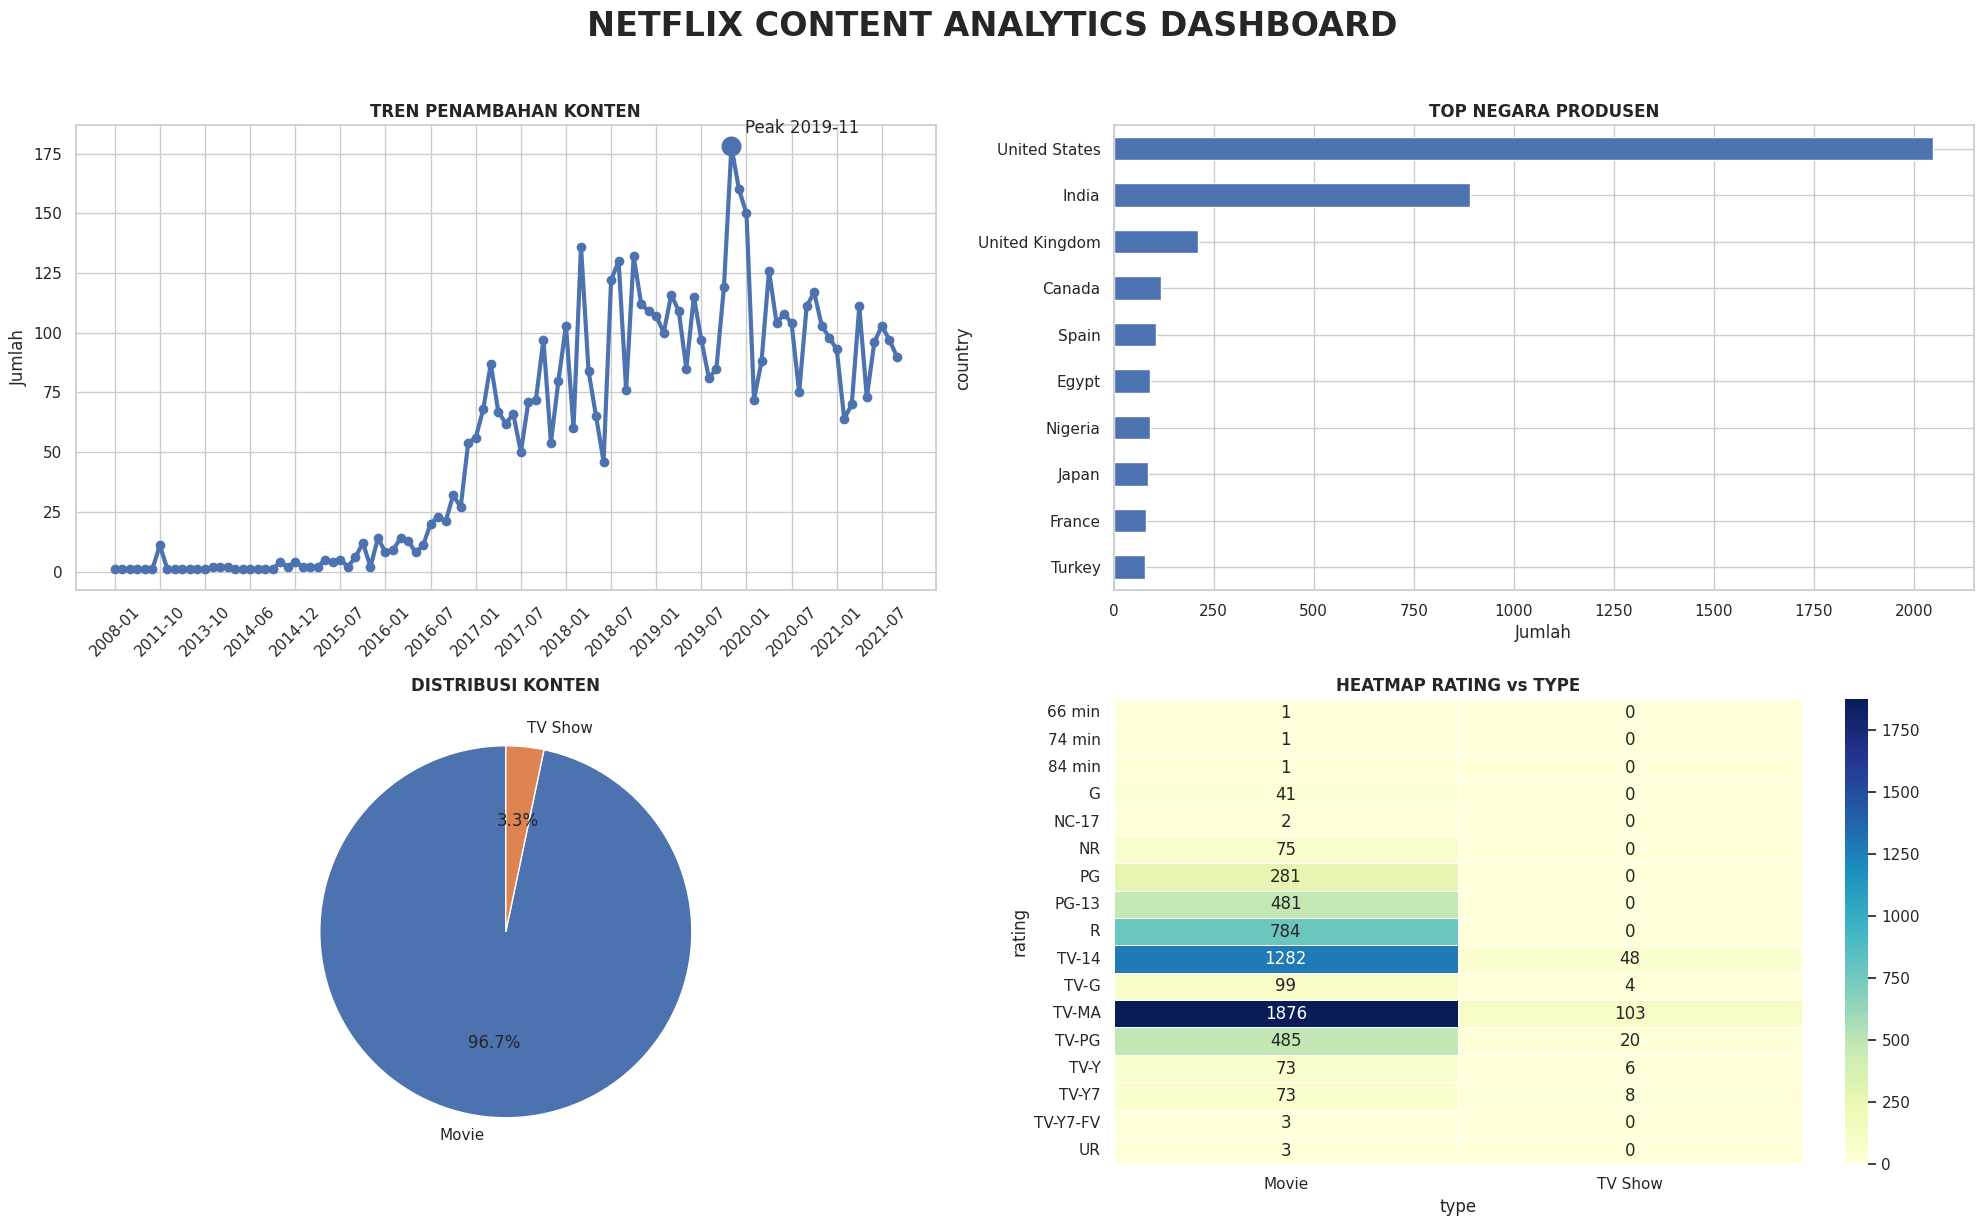

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# CLEAN STYLE
# =========================================
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)
plt.rcParams['axes.titleweight'] = 'bold'

# =========================================
# PREP DATA
# =========================================
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['Month'] = df['date_added'].dt.to_period('M').astype(str)

monthly = df.groupby('Month').size()

top_country = df['country'].dropna().value_counts().head(10)
type_count = df['type'].value_counts()

heat = pd.crosstab(df['rating'], df['type'])

# =========================================
# DASHBOARD LAYOUT RAPI
# =========================================
fig, axes = plt.subplots(2, 2, figsize=(20,12))
fig.suptitle("NETFLIX CONTENT ANALYTICS DASHBOARD", fontsize=24, fontweight='bold', y=1.02)

# ====================================================
# 1. LINE CHART
# ====================================================
ax = axes[0,0]

# biar label x tidak penuh
show_every = 6

ax.plot(monthly.index, monthly.values, linewidth=3, marker='o')

peak_idx = monthly.values.argmax()

ax.scatter(monthly.index[peak_idx], monthly.values[peak_idx], s=180)

ax.annotate(
    f"Peak {monthly.index[peak_idx]}",
    (monthly.index[peak_idx], monthly.values[peak_idx]),
    xytext=(10,10),
    textcoords='offset points'
)

ax.set_title("TREN PENAMBAHAN KONTEN")
ax.set_ylabel("Jumlah")
ax.set_xticks(range(0, len(monthly.index), show_every))
ax.set_xticklabels(monthly.index[::show_every], rotation=45)

# ====================================================
# 2. BARH TOP COUNTRY
# ====================================================
ax = axes[0,1]

top_country.sort_values().plot(kind='barh', ax=ax)

ax.set_title("TOP NEGARA PRODUSEN")
ax.set_xlabel("Jumlah")

# ====================================================
# 3. PIE CHART
# ====================================================
ax = axes[1,0]

ax.pie(
    type_count.values,
    labels=type_count.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor':'white'}
)

ax.set_title("DISTRIBUSI KONTEN")

# ====================================================
# 4. HEATMAP
# ====================================================
ax = axes[1,1]

sns.heatmap(
    heat,
    cmap='YlGnBu',
    annot=True,
    fmt='d',
    linewidths=0.5,
    ax=ax
)

ax.set_title("HEATMAP RATING vs TYPE")

# =========================================
# RAPIIIN SEMUA
# =========================================
plt.tight_layout()

# =========================================
# INSIGHT
# =========================================
print("INSIGHT ANALYST:")
print(f"- Peak upload terjadi di {monthly.idxmax()}")
print(f"- Negara dominan: {top_country.idxmax()}")
print(f"- Konten didominasi: {type_count.idxmax()}")
print("- Heatmap menunjukkan rating populer per tipe konten")

plt.show()